# Student ID: S225135766
# Target Grade: HD
# SIT 788-  Task 2.1P

### Importing Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Importing 2 data sets

In [2]:
df_mushroom = pd.read_csv('mushrooms.csv')

df_mushroom.info()
df_mushroom.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [3]:
## Importing CKD Dataset
#!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df_ckd = fetch_ucirepo(id=336) 
  
# metadata 
print(df_ckd.metadata) 
  
# variable information 
print(df_ckd.variables) 


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

# Data set Description & Problem Statement

### 1. CKD Data Set

The dataset comprises 25 columns, 24 features and one target variable (class). Features include 11 numerical measurements.A significant data quality challenge was identified during pre-analysis: the dataset contains 1,013 missing cells across 24 of 25 columns, representing 10.1% of all data. The rbc column alone has 38% missing values. Additional issues include tab/space-polluted categorical values (e.g., '\tno', ' yes' in the dm column), one corrupted class label ('no' instead of 'ckd'/'notckd'), and three ARFF rows with a trailing empty column. These issues were systematically identified and resolved during preprocessing.

The classification problem involves predicting whether a patient has chronic kidney disease (ckd) or does not (notckd) based on 24 clinical features. Early and accurate diagnosis of CKD is clinically critical, the disease often progresses silently until it reaches an advanced stage. A model with ***high recall for the positive (CKD) class*** is therefore essential, as ***false negatives (missing a sick patient) carry greater clinical risk than false positives***.

### 2. Mushroom Data Set

The Mushroom Classification dataset was sourced from Kaggle (UCI Machine Learning repository). It contains 8,124 records describing physical characteristics of mushrooms from 23 species of the Agaricus and Lepiota family. Each mushroom is labelled as either edible (e) or poisonous (p).
The dataset contains 23 columns, 22 features and one target variable. All features are nominal categorical variables encoded as single-letter codes.

The veil-type column contains zero variance (every row equals 'p') and was removed before modelling, and the stalk-root column uses '?' to encode missing values rather than leaving cells blank.

The classification problem involves predicting mushroom edibility from physical characteristics alone. This is a safety-critical task; consuming a poisonous mushroom can be fatal. As with CKD, ***recall for the positive (poisonous) class is the priority metric***, since ***failing to identify a poisonous mushroom as dangerous (false negative) is far more consequential*** than incorrectly classifying an edible mushroom as poisonous (false positive).

# Data set Comparison
| Characteristic | CKD Dataset | Mushroom Dataset |
| :--- | :--- | :--- |
| **Rows** | 400 (small) | 8,124 (large) |
| **Features** | 24 (mixed types) | 21 (all categorical) |
| **Feature Types** | 11 numeric, 14 categorical | All nominal categorical |
| **Missing Values** | YES, up to 38% in rbc | 1 column (stalk-root uses '?') |
| **Class Balance** | 63% CKD / 37% notCKD | 52% edible / 48% poisonous |
| **Data Quality Issues** | Tabs, corrupted labels | Zero-variance column, '?' missing |




# ML Pipeline

| Stage | Process | Key Actions |
| :--- | :--- | :--- |
| **1. Data Ingestion** | Load CKD ARFF / Mushroom CSV | Convert `?` → `NaN` |
| **2. Data Preparation** | Strip whitespace / Fix labels | Impute missing values & Label encode |
| **3. Train/Test Split** | 80% Train / 20% Test | `stratify=y`, `random_state=42` |
| **4. Model Training** | DecisionTree & RandomForest | Use `gini` criterion for both |
| **5. Model Evaluation** | Performance Metrics | Accuracy, F1-Score, Confusion Matrix, 5-Fold CV |
| **6. Model Export** | `pickle.dump()` | Save best model as `.pkl` |

### EDA - Mushroom Data Set ( df_mushroom)

In [4]:
# Store a copy of the Mushrooms data set

df_m1 = df_mushroom.copy()

print(df_m1.describe())
print(df_m1.isnull().sum())
print(df_m1.nunique())

       class cap-shape cap-surface cap-color bruises  odor gill-attachment  \
count   8124      8124        8124      8124    8124  8124            8124   
unique     2         6           4        10       2     9               2   
top        e         x           y         n       f     n               f   
freq    4208      3656        3244      2284    4748  3528            7914   

       gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
count          8124      8124       8124  ...                     8124   
unique            2         2         12  ...                        4   
top               c         b          b  ...                        s   
freq           6812      5612       1728  ...                     4936   

       stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
count                    8124                   8124      8124       8124   
unique                      9                      9         1          4   
top    

### Data Preprocessing - Mushrooms dataset

In [5]:
#Check unique values for object data types
for col in df_m1.select_dtypes(include='object').columns:
    n = df_m1[col].nunique()
    vals = sorted(df_m1[col].dropna().unique())
    print(f"{col:10} | unique: {n:3} | values: {vals}")


class      | unique:   2 | values: ['e', 'p']
cap-shape  | unique:   6 | values: ['b', 'c', 'f', 'k', 's', 'x']
cap-surface | unique:   4 | values: ['f', 'g', 's', 'y']
cap-color  | unique:  10 | values: ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises    | unique:   2 | values: ['f', 't']
odor       | unique:   9 | values: ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment | unique:   2 | values: ['a', 'f']
gill-spacing | unique:   2 | values: ['c', 'w']
gill-size  | unique:   2 | values: ['b', 'n']
gill-color | unique:  12 | values: ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape | unique:   2 | values: ['e', 't']
stalk-root | unique:   5 | values: ['?', 'b', 'c', 'e', 'r']
stalk-surface-above-ring | unique:   4 | values: ['f', 'k', 's', 'y']
stalk-surface-below-ring | unique:   4 | values: ['f', 'k', 's', 'y']
stalk-color-above-ring | unique:   9 | values: ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
stalk-color-below-ring | unique:   9

In [6]:
# Since Stoalk-root uses '?' for unknown, we need to convert it to 'Nan'

df_m1['stalk-root'] = df_m1['stalk-root'].replace('?',np.nan)

#Since the veil-type have only one value which is 'p' it will not directly contibute to the model. SO we can drop it

df_m1.drop(columns=['veil-type'], inplace = True)

In [7]:
for col in df_m1.select_dtypes(include='object').columns:
    n = df_m1[col].nunique()
    vals = sorted(df_m1[col].dropna().unique())
    print(f"{col:10} | unique: {n:3} | values: {vals}")


class      | unique:   2 | values: ['e', 'p']
cap-shape  | unique:   6 | values: ['b', 'c', 'f', 'k', 's', 'x']
cap-surface | unique:   4 | values: ['f', 'g', 's', 'y']
cap-color  | unique:  10 | values: ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises    | unique:   2 | values: ['f', 't']
odor       | unique:   9 | values: ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment | unique:   2 | values: ['a', 'f']
gill-spacing | unique:   2 | values: ['c', 'w']
gill-size  | unique:   2 | values: ['b', 'n']
gill-color | unique:  12 | values: ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape | unique:   2 | values: ['e', 't']
stalk-root | unique:   4 | values: ['b', 'c', 'e', 'r']
stalk-surface-above-ring | unique:   4 | values: ['f', 'k', 's', 'y']
stalk-surface-below-ring | unique:   4 | values: ['f', 'k', 's', 'y']
stalk-color-above-ring | unique:   9 | values: ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
stalk-color-below-ring | unique:   9 | va

In [8]:
print(((df_m1.isnull().sum()/len(df_m1))*100))

class                        0.000000
cap-shape                    0.000000
cap-surface                  0.000000
cap-color                    0.000000
bruises                      0.000000
odor                         0.000000
gill-attachment              0.000000
gill-spacing                 0.000000
gill-size                    0.000000
gill-color                   0.000000
stalk-shape                  0.000000
stalk-root                  30.526834
stalk-surface-above-ring     0.000000
stalk-surface-below-ring     0.000000
stalk-color-above-ring       0.000000
stalk-color-below-ring       0.000000
veil-color                   0.000000
ring-number                  0.000000
ring-type                    0.000000
spore-print-color            0.000000
population                   0.000000
habitat                      0.000000
dtype: float64


In [9]:
print(df_m1['stalk-root'].unique())

# We will use Mode, to impute the nan value

mode_val = df_m1['stalk-root'].mode()[0]

df_m1['stalk-root']= df_m1['stalk-root'].fillna(mode_val)

#Check remaining missing values
print(((df_m1.isnull().sum()/len(df_m1))*100))


['e' 'c' 'b' 'r' nan]
class                       0.0
cap-shape                   0.0
cap-surface                 0.0
cap-color                   0.0
bruises                     0.0
odor                        0.0
gill-attachment             0.0
gill-spacing                0.0
gill-size                   0.0
gill-color                  0.0
stalk-shape                 0.0
stalk-root                  0.0
stalk-surface-above-ring    0.0
stalk-surface-below-ring    0.0
stalk-color-above-ring      0.0
stalk-color-below-ring      0.0
veil-color                  0.0
ring-number                 0.0
ring-type                   0.0
spore-print-color           0.0
population                  0.0
habitat                     0.0
dtype: float64


In [10]:
## Encoding target value - "Class" for Classification

## Encode all columns in the mushroom dataset
from sklearn.preprocessing import LabelEncoder

mushroom_encoder={}

for col in df_m1.columns:
    le = LabelEncoder()
    df_m1[col] = le.fit_transform(df_m1[col].astype(str))
    mushroom_encoder[col] = le

df_m1.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


### EDA - CKD Data set ( df_ckd)

In [11]:
## Store a copy of the ckd data set

df_repo = fetch_ucirepo(id=336) 
print(df_repo.metadata)
print(df_repo.variables)

x = df_repo.data.features  
y = df_repo.data.targets 

df_ckd1 = pd.concat([x, y], axis=1)

print(df_ckd1.shape)
print(df_ckd1.isnull().sum())
print(df_ckd1.head())

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

In [12]:
# Data Precheck

for col in df_ckd1.select_dtypes(include='object').columns:
    n = df_ckd1[col].nunique()
    vals = sorted(df_ckd1[col].dropna().unique())
    print(f"{col:10} | unique: {n:3} | values: {vals}")


#After inspecting the object datatypes, we can see 'dm', and 'class' features have some erros we need to corrected. 

rbc        | unique:   2 | values: ['abnormal', 'normal']
pc         | unique:   2 | values: ['abnormal', 'normal']
pcc        | unique:   2 | values: ['notpresent', 'present']
ba         | unique:   2 | values: ['notpresent', 'present']
htn        | unique:   2 | values: ['no', 'yes']
dm         | unique:   3 | values: ['\tno', 'no', 'yes']
cad        | unique:   2 | values: ['no', 'yes']
appet      | unique:   2 | values: ['good', 'poor']
pe         | unique:   2 | values: ['no', 'yes']
ane        | unique:   2 | values: ['no', 'yes']
class      | unique:   3 | values: ['ckd', 'ckd\t', 'notckd']


In [13]:
# Fixing values in 'dm' and 'class' cols. 

for col in df_ckd1.select_dtypes(include ='object').columns:
    df_ckd1[col] = df_ckd1[col].str.strip() # Remove whitespaces, newlines, tabs etc. 

for col in df_ckd1.select_dtypes(include='object').columns:
    n = df_ckd1[col].nunique()
    vals = sorted(df_ckd1[col].dropna().unique())
    print(f"{col:10} | unique: {n:3} | values: {vals}")



rbc        | unique:   2 | values: ['abnormal', 'normal']
pc         | unique:   2 | values: ['abnormal', 'normal']
pcc        | unique:   2 | values: ['notpresent', 'present']
ba         | unique:   2 | values: ['notpresent', 'present']
htn        | unique:   2 | values: ['no', 'yes']
dm         | unique:   2 | values: ['no', 'yes']
cad        | unique:   2 | values: ['no', 'yes']
appet      | unique:   2 | values: ['good', 'poor']
pe         | unique:   2 | values: ['no', 'yes']
ane        | unique:   2 | values: ['no', 'yes']
class      | unique:   2 | values: ['ckd', 'notckd']


In [14]:
df_ckd1.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [15]:
# check each missing value percentage

print(((df_ckd1.isnull().sum()/len(df_ckd1))*100))

age       2.25
bp        3.00
sg       11.75
al       11.50
su       12.25
rbc      38.00
pc       16.25
pcc       1.00
ba        1.00
bgr      11.00
bu        4.75
sc        4.25
sod      21.75
pot      22.00
hemo     13.00
pcv      17.75
wbcc     26.50
rbcc     32.75
htn       0.50
dm        0.50
cad       0.50
appet     0.25
pe        0.25
ane       0.25
class     0.00
dtype: float64


### Preprosseing CKD Dataset

In [16]:
# We cant drop Na columns,becuasse most of the field has higher percentage of NaN values and will affect the model if we drop it

## Solution : Imputation
from sklearn.impute import SimpleImputer
Numeric_col =['age','bp','sg','al','su','bgr','bu','sod','sc','pot','hemo','pcv','wbcc','rbcc']
Categorical_col=['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane','class'] 

#since from df.describe showed some extream outliers we use Median to impute
num_imputer = SimpleImputer(strategy='median')
df_ckd1[Numeric_col] = num_imputer.fit_transform(df_ckd1[Numeric_col])

#Categorical columns filled with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df_ckd1[Categorical_col] = cat_imputer.fit_transform(df_ckd1[Categorical_col])

#Check remaining missing values
print(((df_ckd1.isnull().sum()/len(df_ckd1))*100))

age      0.0
bp       0.0
sg       0.0
al       0.0
su       0.0
rbc      0.0
pc       0.0
pcc      0.0
ba       0.0
bgr      0.0
bu       0.0
sc       0.0
sod      0.0
pot      0.0
hemo     0.0
pcv      0.0
wbcc     0.0
rbcc     0.0
htn      0.0
dm       0.0
cad      0.0
appet    0.0
pe       0.0
ane      0.0
class    0.0
dtype: float64


In [17]:
# Encoding - We only encode categorical columns

ckd_encoder={}

for col in Categorical_col:
    le = LabelEncoder()
    df_ckd1[col] = le.fit_transform(df_ckd1[col])
    ckd_encoder[col] = le

df_ckd1[Categorical_col]

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,class
0,1,1,0,0,1,1,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,1,0,1,0,1,0
3,1,0,1,0,1,0,0,1,1,1,0
4,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,0,0,0,0,0,0,1
396,1,1,0,0,0,0,0,0,0,0,1
397,1,1,0,0,0,0,0,0,0,0,1
398,1,1,0,0,0,0,0,0,0,0,1


### Train and Test Data Split - Mushroom Data Set

datasets are split 80/20 using train_test_split() with stratify=y and random_state=42. 

5 fold cross-validation is performed using cross_val_score() for all four model-dataset combinations. In 5-fold CV, the training data is divided into 5 equal folds; the model is trained on 4 folds and evaluated on the remaining fold, rotating through all 5 combinations.

In [18]:
from sklearn.model_selection import train_test_split

X_m1 = df_m1.drop(columns = ['class'])
Y_m1 = df_m1['class']

X_Mush_train,X_Mush_test,Y_Mush_train,Y_Mush_test = train_test_split(
    X_m1,
    Y_m1,
    test_size=0.2,
    random_state=42,
    stratify=Y_m1 
)

print(f"Mushroom Split Result:")
print(f"  X_train: {X_Mush_train.shape}  y_train: {Y_Mush_train.shape}")
print(f"  X_test:  {X_Mush_test.shape}   y_test:  {Y_Mush_test.shape}")

Mushroom Split Result:
  X_train: (6499, 21)  y_train: (6499,)
  X_test:  (1625, 21)   y_test:  (1625,)


### Decision Tree - Mushroom

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt_mushroom = DecisionTreeClassifier(
    criterion ='gini',
    max_depth =5,
    min_samples_split = 10,
    min_samples_leaf =4,
    random_state = 42
       
)

dt_mushroom.fit(X_Mush_train,Y_Mush_train)
print(f"Mushroom Decision Tree trained.")
print(f"  Actual depth used: {dt_mushroom.get_depth()}")
print(f"  Number of leaves:  {dt_mushroom.get_n_leaves()}")


Mushroom Decision Tree trained.
  Actual depth used: 5
  Number of leaves:  15


In [20]:
## Predict

y_predict_dt_mush = dt_mushroom.predict(X_Mush_test)
print("First 20 predictions:", y_predict_dt_mush[:20])
print("First 20 actual:     ", Y_Mush_test.values[:20])


First 20 predictions: [1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 1]
First 20 actual:      [1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 1]


In [21]:
#Accuracy
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc_dt_mush = accuracy_score(Y_Mush_test, y_predict_dt_mush)

print(f"Accuracy: {acc_dt_mush*100:.2f}%")


Accuracy: 98.40%



Confusion Matrix:
[[821  21]
 [  5 778]]


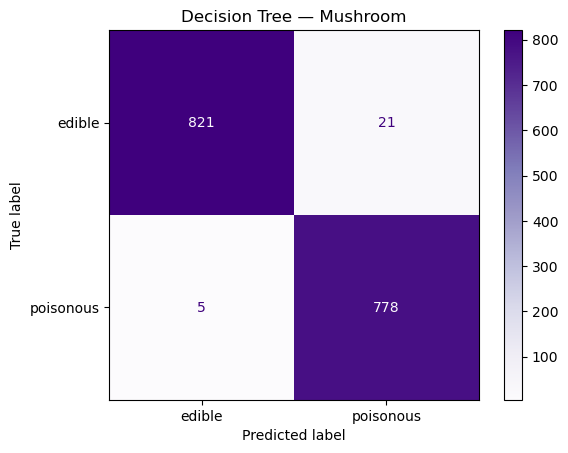

In [22]:
## Confusion Matrix
cm_dt_mush = confusion_matrix(Y_Mush_test, y_predict_dt_mush)
print("\nConfusion Matrix:")
print(cm_dt_mush)

disp = ConfusionMatrixDisplay(cm_dt_mush, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Purples')
plt.title('Decision Tree — Mushroom')
plt.show()

In [23]:
## Classification report 

from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

print(classification_report(Y_Mush_test, y_predict_dt_mush,
                             target_names=['edible', 'poisonous']))

# Cross Validation
cv_dt_mush = cross_val_score(dt_mushroom, X_Mush_train, Y_Mush_train, cv=5, scoring='accuracy')
print(f"CV Scores: {[round(s*100,1) for s in cv_dt_mush]}")
print(f"CV Mean:   {cv_dt_mush.mean()*100:.2f}%")
print(f"CV Std:    ±{cv_dt_mush.std()*100:.2f}%")

              precision    recall  f1-score   support

      edible       0.99      0.98      0.98       842
   poisonous       0.97      0.99      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625

CV Scores: [np.float64(97.5), np.float64(98.2), np.float64(97.4), np.float64(97.5), np.float64(98.1)]
CV Mean:   97.71%
CV Std:    ±0.33%


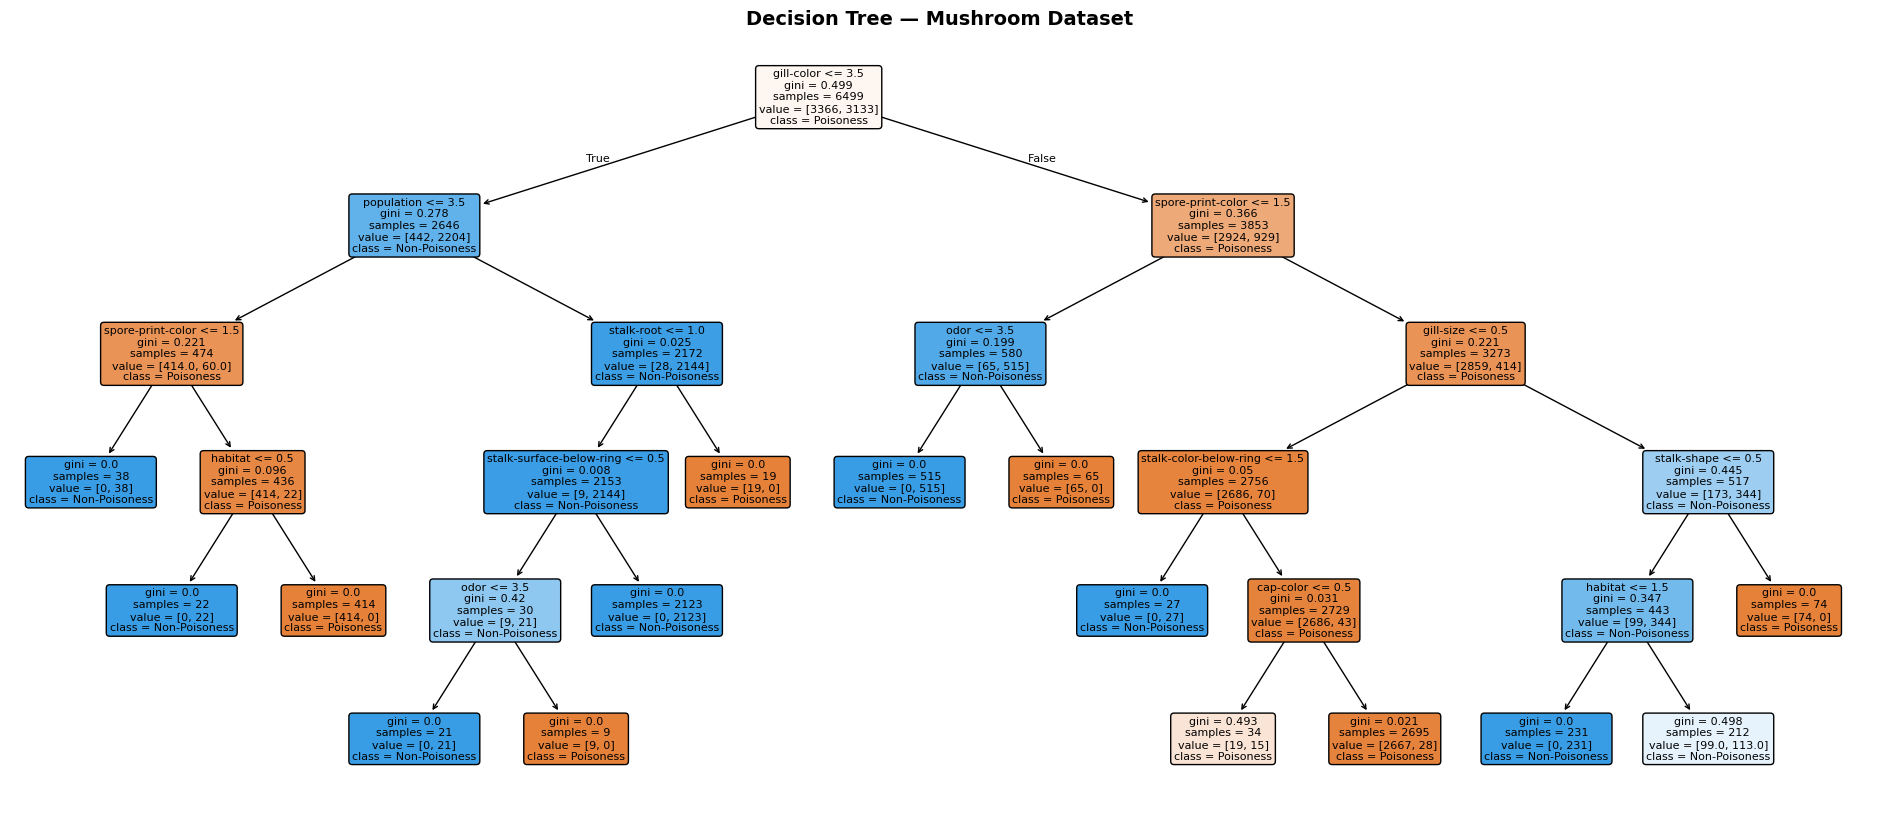

In [24]:
## Visualising the DT 

plt.figure(figsize=(24, 10))
plot_tree(
    dt_mushroom,
    feature_names=X_m1.columns.tolist(),
    class_names=['Poisoness', 'Non-Poisoness'],
    filled=True,   
    rounded=True,    
    fontsize=8
)
plt.title('Decision Tree — Mushroom Dataset', fontsize=14, fontweight='bold')
plt.savefig('dt_Mushroom.png', dpi=150, bbox_inches='tight')
plt.show()

### Train and Test Data Split - CKD Data Set

In [25]:
X_Ckd = df_ckd1.drop(columns='class')
Y_Ckd = df_ckd1['class']

X_ckd_Train,X_ckd_Test,Y_ckd_Train,Y_ckd_Test = train_test_split(
    X_Ckd,
    Y_Ckd,
    test_size = 0.2,
    random_state = 42,
    stratify = Y_Ckd
)

print(f"CKD Split Result:")
print(f"  X_train: {X_ckd_Train.shape}  y_train: {Y_ckd_Train.shape}")
print(f"  X_test:  {X_ckd_Test.shape}   y_test:  {Y_ckd_Test.shape}")

CKD Split Result:
  X_train: (320, 24)  y_train: (320,)
  X_test:  (80, 24)   y_test:  (80,)


### Decision Tree - CKD

In [26]:
dt_ckd = DecisionTreeClassifier(
    criterion ='gini',
    max_depth =5,
    min_samples_split = 10,
    min_samples_leaf =4,
    random_state = 42
       
)

dt_ckd.fit(X_ckd_Train,Y_ckd_Train)
print(f"CKD Decision Tree trained.")
print(f"  Actual depth used: {dt_ckd.get_depth()}")
print(f"  Number of leaves:  {dt_ckd.get_n_leaves()}")

CKD Decision Tree trained.
  Actual depth used: 5
  Number of leaves:  8


In [27]:
## Predict

y_predict_dt_ckd = dt_ckd.predict(X_ckd_Test)
print("First 20 predictions:", y_predict_dt_ckd[:20])
print("First 20 actual:     ", Y_ckd_Test.values[:20])


First 20 predictions: [0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1]
First 20 actual:      [0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1]


Accuracy: 95.00%

Confusion Matrix:
[[49  1]
 [ 3 27]]


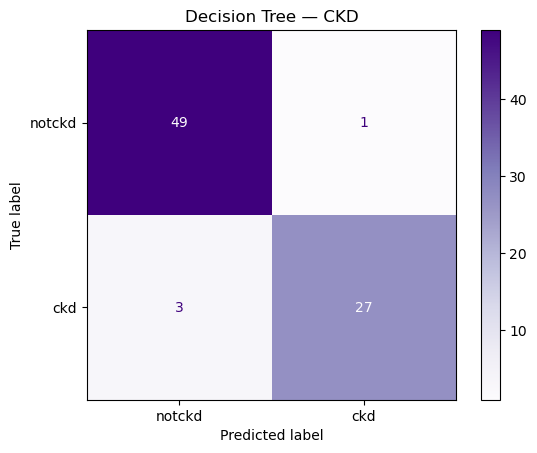

              precision    recall  f1-score   support

      notckd       0.94      0.98      0.96        50
         ckd       0.96      0.90      0.93        30

    accuracy                           0.95        80
   macro avg       0.95      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80

CV Scores: [np.float64(96.9), np.float64(92.2), np.float64(96.9), np.float64(100.0), np.float64(98.4)]
CV Mean:   96.88%
CV Std:    ±2.61%


In [28]:
## Accuracy, COnfusion Matrix and Classification Report

acc_dt_ckd = accuracy_score(Y_ckd_Test, y_predict_dt_ckd)

print(f"Accuracy: {acc_dt_ckd*100:.2f}%")

#Confusion Matrix
cm_dt_ckd = confusion_matrix(Y_ckd_Test, y_predict_dt_ckd)
print("\nConfusion Matrix:")
print(cm_dt_ckd)

disp = ConfusionMatrixDisplay(cm_dt_ckd, display_labels=['notckd', 'ckd'])
disp.plot(cmap='Purples')
plt.title('Decision Tree — CKD')
plt.show()

## Classification report 
print(classification_report(Y_ckd_Test, y_predict_dt_ckd,
                             target_names=['notckd', 'ckd']))

# Cross Validation
cv_dt_ckd = cross_val_score(dt_ckd, X_ckd_Train, Y_ckd_Train, cv=5, scoring='accuracy')
print(f"CV Scores: {[round(s*100,1) for s in cv_dt_ckd]}")
print(f"CV Mean:   {cv_dt_ckd.mean()*100:.2f}%")
print(f"CV Std:    ±{cv_dt_ckd.std()*100:.2f}%")

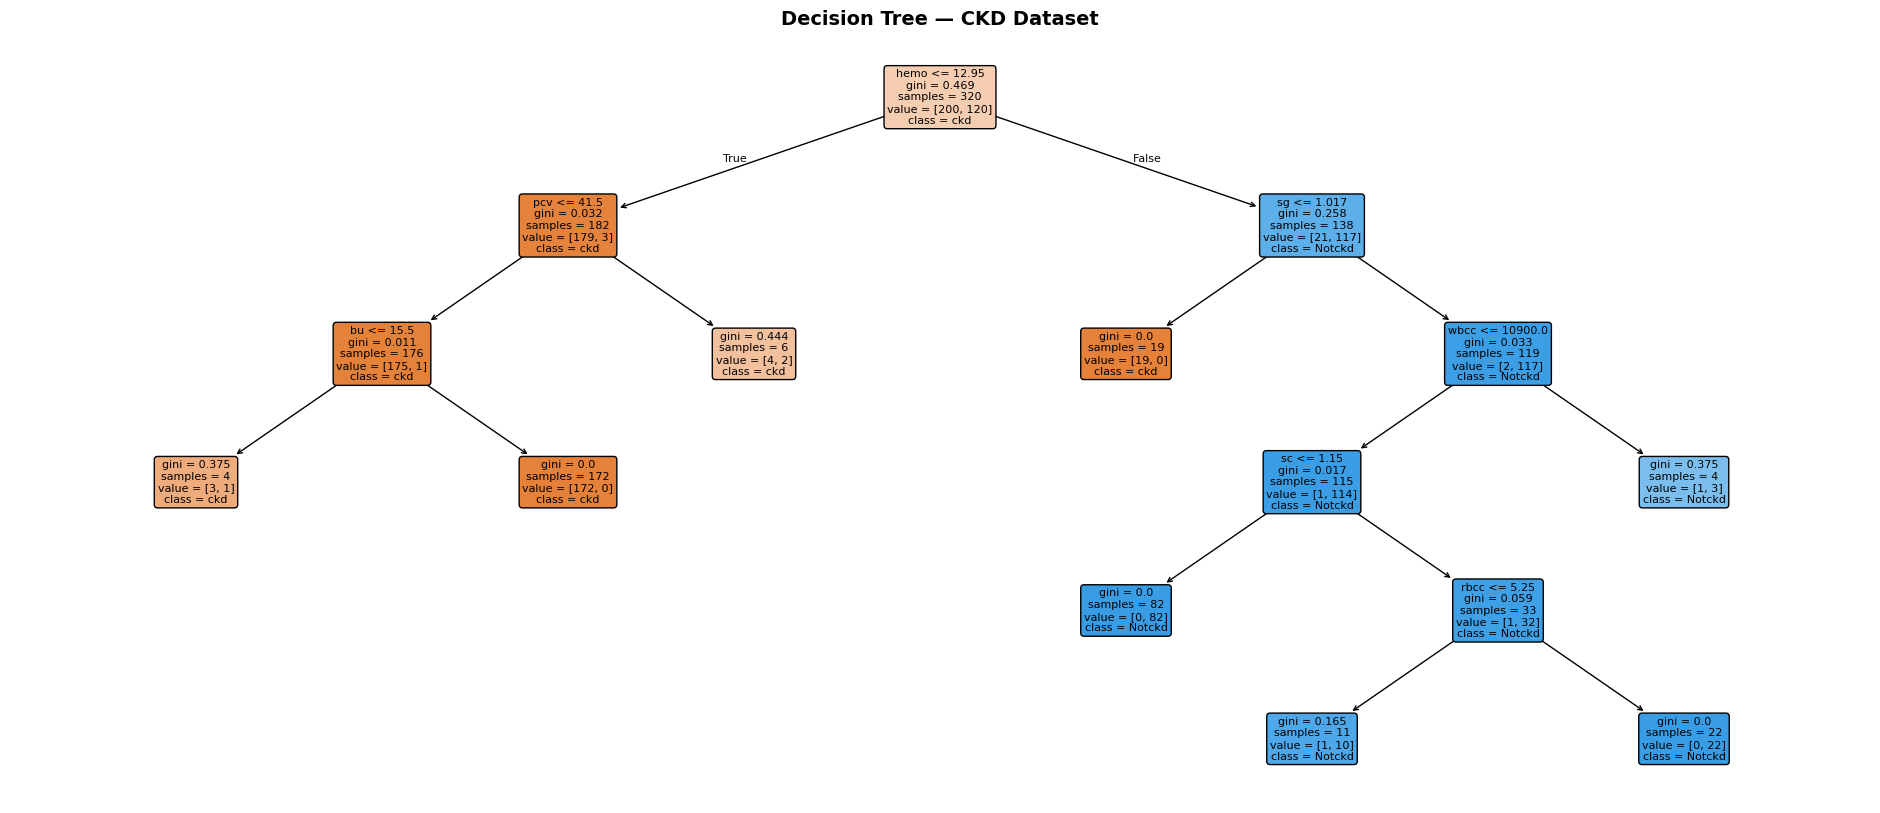

In [29]:
## Visualising the DT 

plt.figure(figsize=(24, 10))
plot_tree(
    dt_ckd,
    feature_names=X_Ckd.columns.tolist(),
    class_names=['ckd', 'Notckd'],
    filled=True,   
    rounded=True,    
    fontsize=8
)
plt.title('Decision Tree — CKD Dataset', fontsize=14, fontweight='bold')
plt.savefig('dt_ckd.png', dpi=150, bbox_inches='tight')
plt.show()

### Random Forest on Mushroom Data set

First 10 predictions: [1 1 0 1 1 0 0 0 0 1]
First 10 actual:      [1 1 0 1 1 0 0 0 0 1]

Accuracy: 100.00%

Confusion Matrix:
[[842   0]
 [  0 783]]


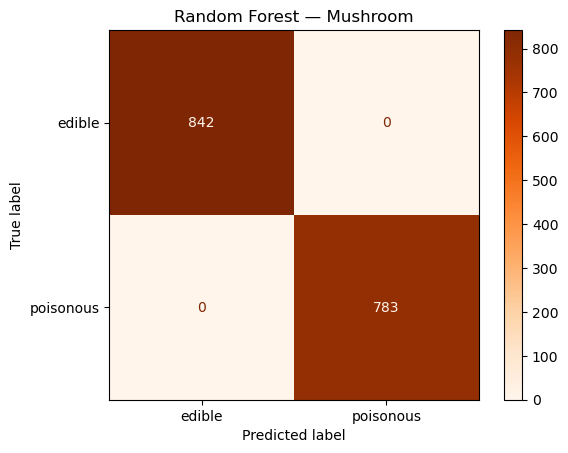

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

CV Scores: [np.float64(99.7), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
CV Mean:   99.94%
CV Std:    ±0.12%


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_mush = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_mush.fit(X_Mush_train, Y_Mush_train)
y_pred_rf_mush = rf_mush.predict(X_Mush_test)

print("First 10 predictions:", y_pred_rf_mush[:10])
print("First 10 actual:     ", Y_Mush_test.values[:10])

#Accuracy
acc_rf_mush = accuracy_score(Y_Mush_test, y_pred_rf_mush)
print(f"\nAccuracy: {acc_rf_mush*100:.2f}%")

#Confusion Matrix
cm_rf_mush = confusion_matrix(Y_Mush_test, y_pred_rf_mush)
print("\nConfusion Matrix:")
print(cm_rf_mush)

disp = ConfusionMatrixDisplay(cm_rf_mush, display_labels=['edible', 'poisonous'])
disp.plot(cmap='Oranges')
plt.title('Random Forest — Mushroom')
plt.show()

#Classification Report
print(classification_report(Y_Mush_test, y_pred_rf_mush,
                             target_names=['edible', 'poisonous']))

#Cross Validation
cv_rf_mush = cross_val_score(rf_mush, X_Mush_train, Y_Mush_train, cv=5, scoring='accuracy')
print(f"CV Scores: {[round(s*100,1) for s in cv_rf_mush]}")
print(f"CV Mean:   {cv_rf_mush.mean()*100:.2f}%")
print(f"CV Std:    ±{cv_rf_mush.std()*100:.2f}%")


### Random Forest on CKD Data Set

First 10 predictions: [0 0 1 1 1 0 0 0 1 0]
First 10 actual:      [0 0 1 1 1 0 0 0 1 0]

Accuracy: 97.50%

Confusion Matrix:
[[50  0]
 [ 2 28]]


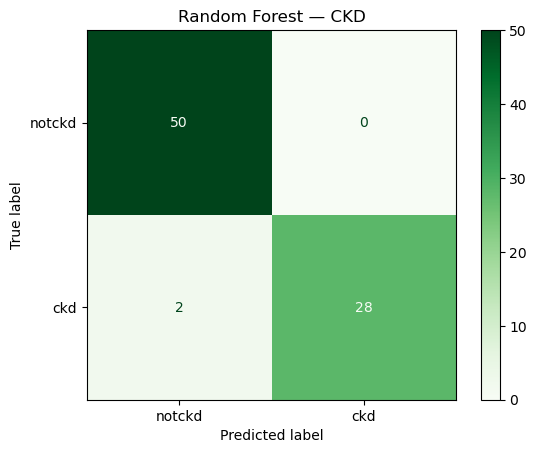

              precision    recall  f1-score   support

      notckd       0.96      1.00      0.98        50
         ckd       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80

CV Scores: [np.float64(98.4), np.float64(98.4), np.float64(98.4), np.float64(100.0), np.float64(98.4)]
CV Mean:   98.75%
CV Std:    ±0.62%


In [31]:
# Train
rf_ckd = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_ckd.fit(X_ckd_Train, Y_ckd_Train)
# Predict
y_pred_rf_ckd = rf_ckd.predict(X_ckd_Test)

print("First 10 predictions:", y_pred_rf_ckd[:10])
print("First 10 actual:     ", Y_ckd_Test.values[:10])

# Accuracy
acc_rf_ckd = accuracy_score(Y_ckd_Test, y_pred_rf_ckd)
print(f"\nAccuracy: {acc_rf_ckd*100:.2f}%")

# Confusion Matrix
cm_rf_ckd = confusion_matrix(Y_ckd_Test, y_pred_rf_ckd)
print("\nConfusion Matrix:")
print(cm_rf_ckd)

disp = ConfusionMatrixDisplay(cm_rf_ckd, display_labels=['notckd', 'ckd'])
disp.plot(cmap='Greens')
plt.title('Random Forest — CKD')
plt.show()

#  Classification Report
print(classification_report(Y_ckd_Test, y_pred_rf_ckd,
                             target_names=['notckd', 'ckd']))

# Cross Validation
cv_rf_ckd = cross_val_score(rf_ckd, X_ckd_Train, Y_ckd_Train, cv=5, scoring='accuracy')
print(f"CV Scores: {[round(s*100,1) for s in cv_rf_ckd]}")
print(f"CV Mean:   {cv_rf_ckd.mean()*100:.2f}%")
print(f"CV Std:    ±{cv_rf_ckd.std()*100:.2f}%")

from sklearn.metrics import f1_score

def show_summary(models_info):
    print("  OVERALL MODEL COMPARISON SUMMARY")
    print("="*50)
    print(f"  {'Model':<16} {'Dataset':<10} {'Test Acc':>10} "
          f"{'F1':>8}{'False Positive':>20}{'False Negative':>20}{'CV Mean':>10} {'CV Std':>8}")
    print("  " + "-"*150)

    for m in models_info:
        print(f"  {m['name']:<16} {m['dataset']:<10} "
              f"{m['acc']*100:>9.2f}% "
              f"{m['f1']:>8.4f} "
              f"{m['cm_fp']:>20} "
              f"{m['cm_fn']:>20} "
              f"{m['cv_mean']*100:>9.2f}% "
              f"±{m['cv_std']*100:>5.2f}%")

    # Find best model
    best = max(models_info, key=lambda x: x['acc'])
    print(f"\n Best Model: {best['name']}")
    print(f"   Accuracy: {best['acc']*100:.2f}%  |  F1: {best['f1']:.4f}")


models_info = [
    {
        'name':    'Decision Tree',
        'dataset': 'CKD',
        'acc':     acc_dt_ckd,
        'f1':      f1_score(Y_ckd_Test,  y_predict_dt_ckd,  average='weighted'),
        'cv_mean': cv_dt_ckd.mean(),
        'cv_std':  cv_dt_ckd.std(),
        'model':   dt_ckd,
        'cm_fp':   cm_dt_ckd[0][1],
        'cm_fn':   cm_dt_ckd[1][0]
        
    },
    {
        'name':    'Random Forest',
        'dataset': 'CKD',
        'acc':     acc_rf_ckd,
        'f1':      f1_score(Y_ckd_Test,  y_pred_rf_ckd,  average='weighted'),
        'cv_mean': cv_rf_ckd.mean(),
        'cv_std':  cv_rf_ckd.std(),
        'model':   rf_ckd,
        'cm_fp':   cm_rf_ckd[0][1],
        'cm_fn':   cm_rf_ckd[1][0]
    },
    {
        'name':    'Decision Tree',
        'dataset': 'Mushroom',
        'acc':     acc_dt_mush,
        'f1':      f1_score(Y_Mush_test, y_predict_dt_mush, average='weighted'),
        'cv_mean': cv_dt_mush.mean(),
        'cv_std':  cv_dt_mush.std(),
        'model':   dt_mushroom,
        'cm_fp':   cm_dt_mush[0][1],
        'cm_fn':   cm_dt_mush[1][0]
    },
    {
        'name':    'Random Forest',
        'dataset': 'Mushroom',
        'acc':     acc_rf_mush,
        'f1':      f1_score(Y_Mush_test, y_pred_rf_mush, average='weighted'),
        'cv_mean': cv_rf_mush.mean(),
        'cv_std':  cv_rf_mush.std(),
        'model':   rf_mush,
        'cm_fp':   cm_rf_mush[0][1],
        'cm_fn':   cm_rf_mush[1][0]
    },
]

show_summary(models_info)

### The Random Forest shows higher metrics than the Decision Tree on all four evaluation metrics across both datasets.

#### On CKD, the Random Forest achieved 97.50% accuracy and F1=0.9748, while the Decision Tree achieved 95.00% and F1=0.9496, with tighter cross-validation stability (±0.62% vs ±2.61%). Further, the Random Forest reduced False Negatives on the CKD test set from 3 to 2,  provided that one fewer patient with kidney disease was missed. This is very critical in sensitive data prediction, like medical diagnosis.  On Mushroom, the Random Forest achieved perfect classification (100% accuracy, F1=1.0, zero False Negatives) versus 5 False Negatives for the Decision Tree. No evidence of overfitting was observed in either model, as cross-validation scores closely matched test set performance across all folds.

### Exporting best model

In [47]:
import pickle

# Initialising the best models for the 2 datasets

best_ckd = rf_ckd
best_mush = rf_mush

ckd_file = 'best_ckd_model.pkl'
mush_file  = 'best_mush_model.pkl'

file = open(ckd_file,'wb')
pickle.dump(best_ckd,file)
file.close()
print("CKD Model exported")

file = open(mush_file,'wb')
pickle.dump(best_mush,file)
file.close()
print("Mush Model exported")




CKD Model exported
Mush Model exported
